In [1]:
# Core libraries for preprocessing, modeling, and visualization
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import pyLDAvis.sklearn  # plotting
import regex  # regular expressions
import sklearn  # machine learning

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg)


Bad key text.latex.preview in file c:\Users\fajayi\AppData\Local\anaconda3\envs\UML\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file c:\Users\fajayi\AppData\Local\anaconda3\envs\UML\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file c:\Users\fajayi\AppData\Local\anaconda3\envs\UML\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 418 ('savefig.jpeg_quality: 95 

# 1. Executive Summary

This notebook develops an end-to-end unsupervised topic-modeling workflow for movie-review intelligence. The use case is to help stakeholders understand what audiences discuss most often so they can improve content curation, recommendation strategy, and marketing decisions. The analysis uses text reviews from IMDB Dataset.csv. Preprocessing included language checking, URL/punctuation/number removal, lowercasing, stop-word filtering, lemmatization, and minimum-length filtering before rebuilding clean documents for modeling.

Model development compared two pipelines: six LDA models trained on CountVectorizer features and six NMF models trained on TF-IDF features, with varied n-grams, min_df/max_df, topic counts, and iteration settings. Each experiment produced hyperparameter records, perplexity (or NMF proxy perplexity), word-topic tables, and document-topic tables, followed by best-model selection and visualization with pyLDAvis plus t-SNE.

The best overall model was LDA_5 because it combined the strongest LDA perplexity (594.6600) with clearer, more coherent themes and stable visual structure. Topics captured interpretable review dimensions such as horror/action content, acting and performance quality, humor/comedy, series-episode discussion, and broad sentiment/opinion language. These themes directly support stakeholder decisions by surfacing what drives audience reactions at scale. NMF_6 remains a useful secondary cross-check for topic labels.

# Load and Examine the data


In [2]:

import pandas


path = "IMDB Dataset.csv"
df = pandas.read_csv(path, header=0)

In [3]:
# define quick look function for data frame

def dataframe_quick_look(df, nrows):
    print("SHAPE:\n{shape}\n".format(shape=df.shape))
    print("COLUMN NAMES:\n{names}\n".format(names=df.columns))
    print("HEAD:\n{head}\n".format(head=df.head(nrows)))

In [4]:
dataframe_quick_look(df, nrows=2)

SHAPE:
(50000, 2)

COLUMN NAMES:
Index(['review', 'sentiment'], dtype='object')

HEAD:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive



In [5]:
# lets look at the final data we are going to move forward with, we are moving on with the review column

raw = df["review"].tolist()
print("REVIEWS:\n{lines}\n".format(lines=raw[:5]))
print("LENGTH:\n{length}\n".format(length=len(raw)))

REVIEWS:
["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [6]:
# select one Review to use as an example

example = raw[5]
print(example)

Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my having seen it some 15 or more times in the last 25 years. Paul Lukas' performance brings tears to my eyes, and Bette Davis, in one of her very few truly sympathetic roles, is a delight. The kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. And the mother's slow awakening to what's happening in the world and under her own roof is believable and startling. If I had a dozen thumbs, they'd all be "up" for this movie.


In [7]:
# check language of Review
# filter to english only

def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

In [8]:
print("DETECTED LANGUAGE:\n{lang}\n".format(lang=do_language_identifying(example)))

DETECTED LANGUAGE:
en



# 2 Preprocessing

Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization.

In [9]:
# perform lemmatization
# uses wordnet dictionary previously loaded

def do_lemmatizing(wrd):
    out = nltk.corpus.wordnet.morphy(wrd)
    return (wrd if out is None else out)

In [10]:
# define consolidated data cleaning function

def do_headline_cleaning(txt):
    # identify language of tweet
    # return null if language not english
    lg = do_language_identifying(txt)
    if lg != 'en':
        return None
    
    # split the string on whitespace
    out = txt.split(" ")
    
    # identify urls
    # replace with URL
    out = ['URL' if bool(regex.search("http[s]?://", i)) else i for i in out]
    
    # remove all punctuation
    out = [regex.sub("[^\\w\\s]|\n", "", i) for i in out]
    
    # remove all numerics
    out = [regex.sub("^[0-9]*$", "", i) for i in out]
    
    # make all non-keywords lowercase
    out = [i.lower() if i not in ["URL"] else i for i in out]
    
    # remove URL
    out = [i for i in out if i not in ["URL",""]]
    
    # remove stopwords
    list_stop_words = nltk.corpus.stopwords.words("english")
    list_stop_words = [regex.sub("[^\\w\\s]", "", i) for i in list_stop_words]
    
    out = [i for i in out if i not in list_stop_words]
    
    # lemmatizing
    out = [do_lemmatizing(i) for i in out]
    
    # keep words 5 or more characters long
    out = [i for i in out if len(i) >= 5]
    
    return out

from time import time

#

In [11]:
# execute function to perform the cleaning
# takes several minutes
tick = time()
clean = list(map(do_headline_cleaning, raw))
print(time()-tick)

549.1916491985321


In [12]:
# remove none types

clean = list(filter(None.__ne__, clean))
print("REVIEW:\n{lines}\n".format(lines=clean[:5]))
print("LENGTH:\n{length}\n".format(length=len(clean)))

REVIEW:
[['reviewer', 'mention', 'watching', 'episode', 'right', 'exactly', 'happen', 'first', 'thing', 'strike', 'brutality', 'unflinching', 'scene', 'violence', 'right', 'trust', 'faint', 'hearted', 'timid', 'punch', 'regard', 'violence', 'hardcore', 'classic', 'wordbr', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'experimental', 'section', 'prison', 'glass', 'front', 'inwards', 'privacy', 'agenda', 'manyaryans', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffle', 'death', 'stare', 'dodgy', 'dealings', 'shady', 'agreement', 'never', 'awaybr', 'would', 'appeal', 'forget', 'pretty', 'picture', 'paint', 'mainstream', 'audience', 'forget', 'charm', 'forget', 'romanceoz', 'around', 'first', 'episode', 'strike', 'nasty', 'surreal', 'ready', 'watch', 'develop', 'taste', 'accustom', 'level', 'graphic', 'violence', 'violence', 'injustice', 'crook', 'guard', 'wholl', 'nickel', 'inmate', 'wholl', 'o

In [13]:
# turn tokens back into string
# concatenate with white spaces

clean_sentences = [" ".join(i) for i in clean]

In [14]:
print(clean_sentences[0:10])

['reviewer mention watching episode right exactly happen first thing strike brutality unflinching scene violence right trust faint hearted timid punch regard violence hardcore classic wordbr nickname given oswald maximum security state penitentary focus mainly emerald experimental section prison glass front inwards privacy agenda manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealings shady agreement never awaybr would appeal forget pretty picture paint mainstream audience forget charm forget romanceoz around first episode strike nasty surreal ready watch develop taste accustom level graphic violence violence injustice crook guard wholl nickel inmate wholl order mannered middle class inmate prison bitch street skill prison experience watching become comfortable uncomfortable viewingthats touch', 'wonderful little production filming technique unassuming oldtimebbc fashion comfort sometimes discomforting sense realism entire piece actor extremel

# 3. Models

Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

In [15]:
# 3.1 LDA Topic Models (CountVectorizer)
print("=" * 100)
print("3.1 LDA TOPIC MODELS (COUNTVECTORIZER)")
print("=" * 100)

# define some global variables
number_words = 10
number_docs = 10
number_features = 1000

# use preprocessed text built in Section 2
texts_for_modeling = clean_sentences

# execute bag-of-words model for LDA
vectorizer1 = sklearn.feature_extraction.text.CountVectorizer(
    analyzer="word",
    ngram_range=(1, 1),
    max_df=0.5,
    min_df=20,
    max_features=number_features
)
clean_vec1 = vectorizer1.fit_transform(texts_for_modeling)
print("Sample sparse row from CountVectorizer:")
print(clean_vec1[0])

try:
    feature_names_vec1 = vectorizer1.get_feature_names_out().tolist()
except AttributeError:
    feature_names_vec1 = vectorizer1.get_feature_names()


def topic_word_table(model, feature_names, n_top_words=10):
    rows = []
    for i, weights in enumerate(model.components_):
        top_idx = np.argsort(weights)[::-1][:n_top_words]
        rows.append({
            "Topic": f"Topic {i + 1}",
            "Top Words": ", ".join(feature_names[j] for j in top_idx)
        })
    return pandas.DataFrame(rows)


def document_topic_table(doc_topic_matrix, n_docs=10):
    doc_df = pandas.DataFrame(doc_topic_matrix)
    doc_df.columns = [f"Topic {i + 1}" for i in range(doc_df.shape[1])]
    doc_df.insert(0, "Dominant Topic", doc_df.idxmax(axis=1))
    doc_df.insert(0, "Document", np.arange(1, len(doc_df) + 1))
    return doc_df.head(n_docs)


def perplexity_by_ntopic(data, ntopics):
    output_dict = {
        "Number Of Topics": [],
        "Perplexity Score": []
    }

    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="online",
            random_state=0,
            max_iter=25
)
        lda.fit(data)

        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(float(lda.perplexity(data)))

    output_df = pandas.DataFrame(output_dict)
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[index_min_perplexity, "Number Of Topics"]
    return output_df, output_num_topics


# quick topic-count scan for LDA
lda_topic_scan, best_lda_topics_from_scan = perplexity_by_ntopic(clean_vec1, [2, 3, 4, 5, 6, 7])
print("\nLDA topic-count scan")
display(lda_topic_scan)
print(f"Suggested LDA topics from scan: {best_lda_topics_from_scan}")

lda_specs = [
    {
        "experiment": "LDA_1",
        "vectorizer": {"ngram_range": (1, 1), "max_df": 0.50, "min_df": 20, "max_features": number_features},
        "model": {"n_components": 2, "learning_method": "online", "max_iter": 25, "random_state": 0},
    },
    {
        "experiment": "LDA_2",
        "vectorizer": {"ngram_range": (1, 1), "max_df": 0.50, "min_df": 15, "max_features": number_features},
        "model": {"n_components": 3, "learning_method": "online", "max_iter": 25, "random_state": 0},
    },
    {
        "experiment": "LDA_3",
        "vectorizer": {"ngram_range": (1, 1), "max_df": 0.60, "min_df": 15, "max_features": number_features},
        "model": {"n_components": 4, "learning_method": "online", "max_iter": 30, "random_state": 0},
    },
    {
        "experiment": "LDA_4",
        "vectorizer": {"ngram_range": (1, 2), "max_df": 0.60, "min_df": 15, "max_features": number_features},
        "model": {"n_components": 5, "learning_method": "online", "max_iter": 30, "random_state": 0},
    },
    {
        "experiment": "LDA_5",
        "vectorizer": {"ngram_range": (1, 2), "max_df": 0.70, "min_df": 10, "max_features": number_features},
        "model": {"n_components": 6, "learning_method": "batch", "max_iter": 35, "random_state": 0},
    },
    {
        "experiment": "LDA_6",
        "vectorizer": {"ngram_range": (1, 2), "max_df": 0.80, "min_df": 10, "max_features": number_features},
        "model": {"n_components": 7, "learning_method": "batch", "max_iter": 35, "random_state": 0},
    },
]

lda_records = []
nmf_records = []
fitted_models = {}
experiment_tables = {}

for spec in lda_specs:
    vec = sklearn.feature_extraction.text.CountVectorizer(
        analyzer="word",
        ngram_range=spec["vectorizer"]["ngram_range"],
        max_df=spec["vectorizer"]["max_df"],
        min_df=spec["vectorizer"]["min_df"],
        max_features=spec["vectorizer"]["max_features"],
    )
    dtm = vec.fit_transform(texts_for_modeling)

    lda = sklearn.decomposition.LatentDirichletAllocation(**spec["model"])
    doc_topic = lda.fit_transform(dtm)

    try:
        feature_names = vec.get_feature_names_out().tolist()
    except AttributeError:
        feature_names = vec.get_feature_names()

    w_table = topic_word_table(lda, feature_names, n_top_words=number_words)
    d_table = document_topic_table(doc_topic, n_docs=number_docs)
    perplexity = float(lda.perplexity(dtm))

    model_row = {
        "Experiment": spec["experiment"],
        "Model Type": "LDA",
        "n_topics": spec["model"]["n_components"],
        "ngram_range": spec["vectorizer"]["ngram_range"],
        "min_df": spec["vectorizer"]["min_df"],
        "max_df": spec["vectorizer"]["max_df"],
        "max_features": spec["vectorizer"]["max_features"],
        "learning_method": spec["model"]["learning_method"],
        "max_iter": spec["model"]["max_iter"],
        "Perplexity": perplexity,
    }
    lda_records.append(model_row)

    fitted_models[spec["experiment"]] = {"model": lda, "vectorizer": vec, "dtm": dtm, "doc_topic": doc_topic}
    experiment_tables[spec["experiment"]] = {"word_topic": w_table, "doc_topic": d_table, "params": model_row}

    print(f"\n{spec['experiment']} hyperparameters")
    display(pandas.DataFrame([model_row]))
    print("Word-topic table")
    display(w_table)
    print("Document-topic table (first 10 documents)")
    display(d_table)


print("\n" + "=" * 100)
print("3.2 NMF TOPIC MODELS (TFIDFVECTORIZER)")
print("=" * 100)

# create tf-idf vectors for NMF
vectorizer2 = sklearn.feature_extraction.text.TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 1),
    max_df=0.5,
    min_df=20,
    max_features=number_features
)
clean_vec2 = vectorizer2.fit_transform(texts_for_modeling)
print("Sample sparse row from TfidfVectorizer:")
print(clean_vec2[0])

try:
    feature_names_vec2 = vectorizer2.get_feature_names_out().tolist()
except AttributeError:
    feature_names_vec2 = vectorizer2.get_feature_names()


def nmf_proxy_perplexity(model, matrix):
    # sklearn NMF has no true perplexity; use a monotonic proxy from reconstruction error.
    return float(np.exp(model.reconstruction_err_ / max(matrix.shape[0], 1)))


nmf_specs = [
    {
        "experiment": "NMF_1",
        "vectorizer": {"ngram_range": (1, 1), "max_df": 0.50, "min_df": 20, "max_features": number_features},
        "model": {"n_components": 2, "init": "nndsvda", "solver": "cd", "max_iter": 400, "random_state": 0},
    },
    {
        "experiment": "NMF_2",
        "vectorizer": {"ngram_range": (1, 1), "max_df": 0.50, "min_df": 15, "max_features": number_features},
        "model": {"n_components": 3, "init": "nndsvda", "solver": "cd", "max_iter": 400, "random_state": 0},
    },
    {
        "experiment": "NMF_3",
        "vectorizer": {"ngram_range": (1, 1), "max_df": 0.60, "min_df": 15, "max_features": number_features},
        "model": {"n_components": 4, "init": "nndsvda", "solver": "cd", "max_iter": 500, "random_state": 0},
    },
    {
        "experiment": "NMF_4",
        "vectorizer": {"ngram_range": (1, 2), "max_df": 0.60, "min_df": 15, "max_features": number_features},
        "model": {"n_components": 5, "init": "nndsvdar", "solver": "mu", "beta_loss": "kullback-leibler", "max_iter": 500, "random_state": 0},
    },
    {
        "experiment": "NMF_5",
        "vectorizer": {"ngram_range": (1, 2), "max_df": 0.70, "min_df": 10, "max_features": number_features},
        "model": {"n_components": 6, "init": "nndsvda", "solver": "cd", "max_iter": 500, "random_state": 0},
    },
    {
        "experiment": "NMF_6",
        "vectorizer": {"ngram_range": (1, 2), "max_df": 0.80, "min_df": 10, "max_features": number_features},
        "model": {"n_components": 7, "init": "nndsvda", "solver": "cd", "max_iter": 500, "random_state": 0},
    },
]

for spec in nmf_specs:
    vec = sklearn.feature_extraction.text.TfidfVectorizer(
        analyzer="word",
        ngram_range=spec["vectorizer"]["ngram_range"],
        max_df=spec["vectorizer"]["max_df"],
        min_df=spec["vectorizer"]["min_df"],
        max_features=spec["vectorizer"]["max_features"],
    )
    dtm = vec.fit_transform(texts_for_modeling)

    nmf = sklearn.decomposition.NMF(**spec["model"])
    doc_topic = nmf.fit_transform(dtm)

    try:
        feature_names = vec.get_feature_names_out().tolist()
    except AttributeError:
        feature_names = vec.get_feature_names()

    w_table = topic_word_table(nmf, feature_names, n_top_words=number_words)
    d_table = document_topic_table(doc_topic, n_docs=number_docs)
    proxy_perplexity = nmf_proxy_perplexity(nmf, dtm)

    model_row = {
        "Experiment": spec["experiment"],
        "Model Type": "NMF",
        "n_topics": spec["model"]["n_components"],
        "ngram_range": spec["vectorizer"]["ngram_range"],
        "min_df": spec["vectorizer"]["min_df"],
        "max_df": spec["vectorizer"]["max_df"],
        "max_features": spec["vectorizer"]["max_features"],
        "init": spec["model"].get("init"),
        "solver": spec["model"].get("solver"),
        "max_iter": spec["model"].get("max_iter"),
        "Perplexity": proxy_perplexity,
    }
    nmf_records.append(model_row)

    fitted_models[spec["experiment"]] = {"model": nmf, "vectorizer": vec, "dtm": dtm, "doc_topic": doc_topic}
    experiment_tables[spec["experiment"]] = {"word_topic": w_table, "doc_topic": d_table, "params": model_row}

    print(f"\n{spec['experiment']} hyperparameters")
    display(pandas.DataFrame([model_row]))
    print("Word-topic table")
    display(w_table)
    print("Document-topic table (first 10 documents)")
    display(d_table)


lda_results = pandas.DataFrame(lda_records).sort_values("Perplexity", ascending=True).reset_index(drop=True)
nmf_results = pandas.DataFrame(nmf_records).sort_values("Perplexity", ascending=True).reset_index(drop=True)

best_lda_name = lda_results.iloc[0]["Experiment"]
best_nmf_name = nmf_results.iloc[0]["Experiment"]

print("\n" + "=" * 100)
print("LDA SUMMARY (sorted by lowest perplexity)")
print("=" * 100)
display(lda_results)

print("\n" + "=" * 100)
print("NMF SUMMARY (sorted by lowest proxy perplexity)")
print("=" * 100)
display(nmf_results)

print("\n" + "=" * 100)
print("SELECTED BEST MODELS")
print("=" * 100)
print(f"Best LDA model: {best_lda_name}")
print(f"Best NMF model: {best_nmf_name}")

print("\nBest LDA word-topic table")
display(experiment_tables[best_lda_name]["word_topic"])
print("Best LDA document-topic table")
display(experiment_tables[best_lda_name]["doc_topic"])

print("\nBest NMF word-topic table")
display(experiment_tables[best_nmf_name]["word_topic"])
print("Best NMF document-topic table")
display(experiment_tables[best_nmf_name]["doc_topic"])

3.1 LDA TOPIC MODELS (COUNTVECTORIZER)
Sample sparse row from CountVectorizer:
  (0, 725)	1
  (0, 538)	1
  (0, 964)	2
  (0, 298)	2
  (0, 728)	2
  (0, 308)	1
  (0, 408)	1
  (0, 356)	2
  (0, 893)	1
  (0, 838)	2
  (0, 739)	1
  (0, 954)	4
  (0, 926)	1
  (0, 706)	1
  (0, 162)	1
  (0, 392)	1
  (0, 823)	1
  (0, 359)	1
  (0, 515)	1
  (0, 663)	3
  (0, 375)	1
  (0, 153)	1
  (0, 472)	1
  (0, 223)	1
  (0, 576)	1
  (0, 991)	1
  (0, 53)	1
  (0, 366)	3
  (0, 661)	1
  (0, 630)	1
  (0, 70)	1
  (0, 143)	1
  (0, 58)	1
  (0, 570)	1
  (0, 692)	1
  (0, 963)	1
  (0, 243)	1
  (0, 876)	1
  (0, 497)	1
  (0, 599)	1
  (0, 542)	1
  (0, 161)	1
  (0, 837)	1
  (0, 787)	1
  (0, 318)	1
  (0, 87)	1
  (0, 913)	1

LDA topic-count scan


,Number Of Topics,Perplexity Score
0,2,655.125734
1,3,658.405883
2,4,665.517472
3,5,672.096362
4,6,682.893049
5,7,693.381592


Suggested LDA topics from scan: 2

LDA_1 hyperparameters


,Experiment,Model Type,n_topics,ngram_range,min_df,max_df,max_features,learning_method,max_iter,Perplexity
0,LDA_1,LDA,2,"(1, 1)",20,0.5,1000,online,25,655.125734


Word-topic table


...

,Document,Dominant Topic,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6
0,1,Topic 6,0.250679,0.002857,0.002848,0.002856,0.252878,0.487883
1,2,Topic 4,0.004200,0.474895,0.004199,0.508295,0.004210,0.004201
2,3,Topic 5,0.140127,0.328385,0.004102,0.186437,0.336833,0.004116
3,4,Topic 6,0.190752,0.004688,0.345550,0.033985,0.004679,0.420346
4,5,Topic 6,0.004220,0.004219,0.104283,0.320079,0.094067,0.473132
5,6,Topic 2,0.007620,0.421457,0.238154,0.007628,0.007661,0.317480
6,7,Topic 6,0.099530,0.007988,0.008009,0.007987,0.304867,0.571620
7,8,Topic 5,0.005402,0.201595,0.005435,0.141197,0.640938,0.005434
8,9,Topic 3,0.005714,0.005628,0.585066,0.392308,0.005635,0.005649
9,10,Topic 3,0.024004,0.449899,0.453665,0.024308,0.024141,0.023983



Best NMF word-topic table


,Topic,Top Words
0,Topic 1,"character, story, scene, woman, young, little,..."
1,Topic 2,"movie, movie movie, watch movie, watch, movie ..."
2,Topic 3,"great, actor, performance, really, great movie..."
3,Topic 4,"funny, comedy, laugh, hilarious, humor, moment..."
4,Topic 5,"episode, series, season, first, original, watc..."
5,Topic 6,"really, would, think, people, watch, could, wa..."
6,Topic 7,"horror, effects, special, special effects, hor..."


Best NMF document-topic table


,Document,Dominant Topic,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7
0,1,Topic 5,0.016379,0.000000,0.000000,0.000000,0.044319,0.013080,0.003089
1,2,Topic 3,0.017617,0.000000,0.030623,0.013907,0.000000,0.010893,0.005242
2,3,Topic 4,0.015724,0.000678,0.022284,0.049000,0.000621,0.007296,0.000000
3,4,Topic 2,0.014438,0.026684,0.000000,0.001164,0.003283,0.009083,0.009527
4,5,Topic 1,0.026919,0.009927,0.000000,0.000000,0.000000,0.020250,0.000000
5,6,Topic 2,0.023398,0.033570,0.012867,0.000000,0.004818,0.005912,0.000000
6,7,Topic 6,0.005262,0.000000,0.000000,0.000000,0.036689,0.037461,0.000000
7,8,Topic 4,0.011707,0.001305,0.010633,0.025216,0.024490,0.019554,0.000000
8,9,Topic 6,0.006106,0.002058,0.006086,0.000000,0.000103,0.027684,0.014901
9,10,Topic 3,0.000000,0.065046,0.085051,0.000000,0.004761,0.000000,0.000000


### Best-Model Selection Notes
- LDA best model is selected as the experiment with the lowest LDA perplexity.
- NMF best model is selected as the experiment with the lowest NMF proxy perplexity (because sklearn NMF does not provide true perplexity).
- Use the corresponding word-topic and document-topic tables above to confirm interpretability before final reporting.

In [17]:
# find perplexity scores for several different numbers of topics
# takes several minutes

df_perplexity, optimal_num_topics = perplexity_by_ntopic(
    clean_vec1, 
    ntopics=[1, 2, 3, 4, 6, 8, 10]
)

In [18]:
print(df_perplexity)

   Number Of Topics  Perplexity Score
0                 1        665.440185
1                 2        655.125734
2                 3        658.405883
3                 4        665.517472
4                 6        682.893049
5                 8        709.870212
6                10        722.118147


<AxesSubplot:xlabel='Number Of Topics'>

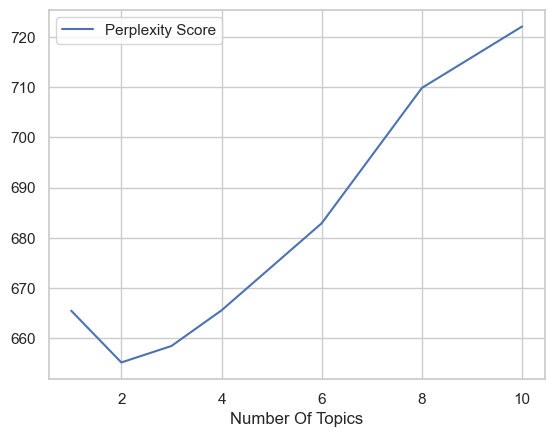

In [19]:
df_perplexity.plot.line("Number Of Topics", "Perplexity Score")

# 4 Discussion

For the best LDA and NMF models, present again the perplexity for each, and display the word-topic and document-topic tables. For your best LDA model, create a biplot visualization using the pyLDAvis package and a t-SNE visualization to explore document-topic relationships in lower-dimensional space. Experiment with values of the relevance metric and be prepared to demonstrate this to your instructor. Write a clear description, in your own words, of the abstract topics found by each model and present this information neatly. Discuss which model has done the best job of identifying topics for your use case and justify this by referring to the analysis and visualizations.

In [29]:
# display perplexity, word-topic, and document-topic tables for the best LDA and NMF models
best_lda_row = lda_results.loc[lda_results["Experiment"] == best_lda_name].iloc[0]
best_nmf_row = nmf_results.loc[nmf_results["Experiment"] == best_nmf_name].iloc[0]

print("\n" + "=" * 100)
print("BEST-MODEL PERPLEXITY SUMMARY")
print("=" * 100)
print(f"Best LDA model: {best_lda_name} | Perplexity: {best_lda_row['Perplexity']:.4f}")
print(f"Best NMF model: {best_nmf_name} | Proxy Perplexity: {best_nmf_row['Perplexity']:.4f}")

print("\n" + "=" * 100)
print("BEST LDA MODEL TABLES")
display(experiment_tables[best_lda_name]["word_topic"])
display(experiment_tables[best_lda_name]["doc_topic"])

print("\n" + "=" * 100)
print("BEST NMF MODEL TABLES")
display(experiment_tables[best_nmf_name]["word_topic"])
display(experiment_tables[best_nmf_name]["doc_topic"])


BEST-MODEL PERPLEXITY SUMMARY
Best LDA model: LDA_5 | Perplexity: 594.6600
Best NMF model: NMF_6 | Proxy Perplexity: 1.0043

BEST LDA MODEL TABLES


,Topic,Top Words
0,Topic 1,"scene, horror, action, murder, killer, story, ..."
1,Topic 2,"movie, great, story, character, performance, r..."
2,Topic 3,"movie, watch, really, would, acting, people, t..."
3,Topic 4,"character, director, actor, scene, story, woul..."
4,Topic 5,"really, funny, character, series, would, first..."
5,Topic 6,"people, woman, would, family, world, story, yo..."


,Document,Dominant Topic,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6
0,1,Topic 6,0.250679,0.002857,0.002848,0.002856,0.252878,0.487883
1,2,Topic 4,0.004200,0.474895,0.004199,0.508295,0.004210,0.004201
2,3,Topic 5,0.140127,0.328385,0.004102,0.186437,0.336833,0.004116
3,4,Topic 6,0.190752,0.004688,0.345550,0.033985,0.004679,0.420346
4,5,Topic 6,0.004220,0.004219,0.104283,0.320079,0.094067,0.473132
5,6,Topic 2,0.007620,0.421457,0.238154,0.007628,0.007661,0.317480
6,7,Topic 6,0.099530,0.007988,0.008009,0.007987,0.304867,0.571620
7,8,Topic 5,0.005402,0.201595,0.005435,0.141197,0.640938,0.005434
8,9,Topic 3,0.005714,0.005628,0.585066,0.392308,0.005635,0.005649
9,10,Topic 3,0.024004,0.449899,0.453665,0.024308,0.024141,0.023983



BEST NMF MODEL TABLES


,Topic,Top Words
0,Topic 1,"character, story, scene, woman, young, little,..."
1,Topic 2,"movie, movie movie, watch movie, watch, movie ..."
2,Topic 3,"great, actor, performance, really, great movie..."
3,Topic 4,"funny, comedy, laugh, hilarious, humor, moment..."
4,Topic 5,"episode, series, season, first, original, watc..."
5,Topic 6,"really, would, think, people, watch, could, wa..."
6,Topic 7,"horror, effects, special, special effects, hor..."


,Document,Dominant Topic,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7
0,1,Topic 5,0.016379,0.000000,0.000000,0.000000,0.044319,0.013080,0.003089
1,2,Topic 3,0.017617,0.000000,0.030623,0.013907,0.000000,0.010893,0.005242
2,3,Topic 4,0.015724,0.000678,0.022284,0.049000,0.000621,0.007296,0.000000
3,4,Topic 2,0.014438,0.026684,0.000000,0.001164,0.003283,0.009083,0.009527
4,5,Topic 1,0.026919,0.009927,0.000000,0.000000,0.000000,0.020250,0.000000
5,6,Topic 2,0.023398,0.033570,0.012867,0.000000,0.004818,0.005912,0.000000
6,7,Topic 6,0.005262,0.000000,0.000000,0.000000,0.036689,0.037461,0.000000
7,8,Topic 4,0.011707,0.001305,0.010633,0.025216,0.024490,0.019554,0.000000
8,9,Topic 6,0.006106,0.002058,0.006086,0.000000,0.000103,0.027684,0.014901
9,10,Topic 3,0.000000,0.065046,0.085051,0.000000,0.004761,0.000000,0.000000


In [22]:
print("\n" + "=" * 100)
print("BEST NMF MODEL TABLES")
display(experiment_tables[best_nmf_name]["word_topic"])
display(experiment_tables[best_nmf_name]["doc_topic"])


BEST NMF MODEL TABLES


,Topic,Top Words
0,Topic 1,"character, story, scene, woman, young, little,..."
1,Topic 2,"movie, movie movie, watch movie, watch, movie ..."
2,Topic 3,"great, actor, performance, really, great movie..."
3,Topic 4,"funny, comedy, laugh, hilarious, humor, moment..."
4,Topic 5,"episode, series, season, first, original, watc..."
5,Topic 6,"really, would, think, people, watch, could, wa..."
6,Topic 7,"horror, effects, special, special effects, hor..."


,Document,Dominant Topic,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7
0,1,Topic 5,0.016379,0.000000,0.000000,0.000000,0.044319,0.013080,0.003089
1,2,Topic 3,0.017617,0.000000,0.030623,0.013907,0.000000,0.010893,0.005242
2,3,Topic 4,0.015724,0.000678,0.022284,0.049000,0.000621,0.007296,0.000000
3,4,Topic 2,0.014438,0.026684,0.000000,0.001164,0.003283,0.009083,0.009527
4,5,Topic 1,0.026919,0.009927,0.000000,0.000000,0.000000,0.020250,0.000000
5,6,Topic 2,0.023398,0.033570,0.012867,0.000000,0.004818,0.005912,0.000000
6,7,Topic 6,0.005262,0.000000,0.000000,0.000000,0.036689,0.037461,0.000000
7,8,Topic 4,0.011707,0.001305,0.010633,0.025216,0.024490,0.019554,0.000000
8,9,Topic 6,0.006106,0.002058,0.006086,0.000000,0.000103,0.027684,0.014901
9,10,Topic 3,0.000000,0.065046,0.085051,0.000000,0.004761,0.000000,0.000000


LENGTH:
49254

COUNTS:
[[    0  4870]
 [    1  7459]
 [    2 12050]
 [    3  8435]
 [    4  8485]
 [    5  7955]]



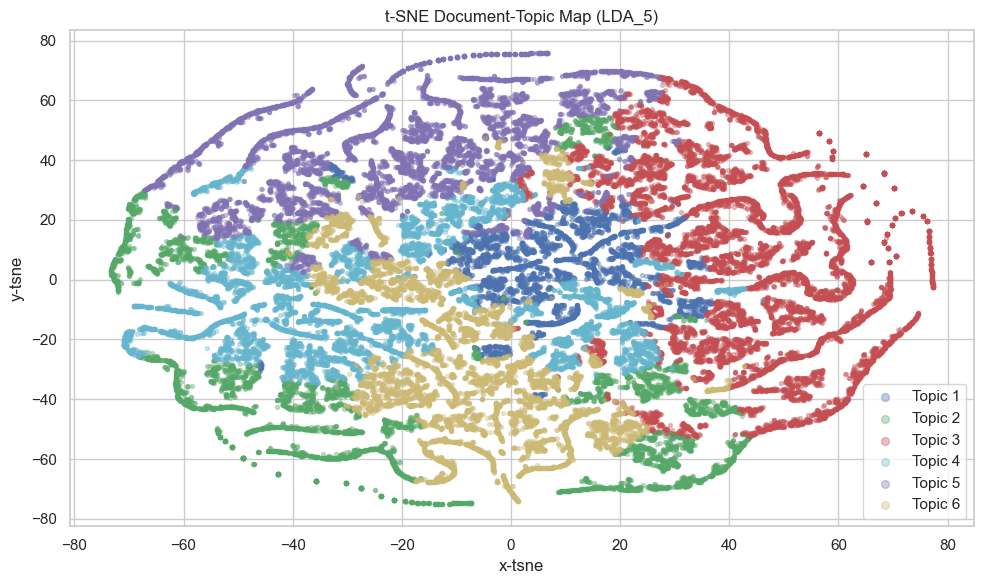

In [28]:
# create a pyLDAvis biplot and a t-SNE document-topic visualization for the best LDA model
best_lda_model = fitted_models[best_lda_name]["model"]
best_lda_vectorizer = fitted_models[best_lda_name]["vectorizer"]
best_lda_dtm = fitted_models[best_lda_name]["dtm"]
best_lda_doc_topic = fitted_models[best_lda_name]["doc_topic"]

# Use single-process mode to avoid worker crashes in some Windows environments
best_lda_pyldavis = pyLDAvis.sklearn.prepare(
    best_lda_model,
    best_lda_dtm,
    best_lda_vectorizer,
    mds="mmds",
    n_jobs=1
)
pyLDAvis.display(best_lda_pyldavis)

# define function to fit and plot t-SNE model
def plot_tsne(data, threshold):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold
    lda_transform_filt = data[index_meet_threshold]

    # fit tsne model: x dimensions -> 2 dimensions
    tsne = sklearn.manifold.TSNE(
        n_components=2,
        verbose=0,
        random_state=0,
        angle=0.5,
        init="pca",
        learning_rate=200
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)

    # most probable topic for each filtered document
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):
        most_prob_topic.append(lda_transform_filt[i].argmax())

    print("LENGTH:\n{}\n".format(len(most_prob_topic)))
    unique, counts = numpy.unique(numpy.array(most_prob_topic), return_counts=True)
    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))

    # make scatter plot per topic
    color_list = ["b", "g", "r", "c", "m", "y", "k"]
    matplotlib.pyplot.figure(figsize=(10, 6))

    for i in list(set(most_prob_topic)):
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0],
            y=tsne_fit[indices, 1],
            s=8,
            c=color_list[i % len(color_list)],
            label="Topic " + str(i + 1),
            alpha=0.35
        )

    matplotlib.pyplot.xlabel("x-tsne")
    matplotlib.pyplot.ylabel("y-tsne")
    matplotlib.pyplot.title(f"t-SNE Document-Topic Map ({best_lda_name})")
    matplotlib.pyplot.legend(markerscale=2)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

# run t-SNE plot for the best LDA model
plot_tsne(best_lda_doc_topic, threshold=0.30)

In [33]:
# map custom titles to best-LDA topics and print top words
best_lda_word_table = experiment_tables[best_lda_name]["word_topic"].copy()

# Clear topic labels for reporting
topic_title_map = {
    "Topic 1": "Action, and Crime Scenes",
    "Topic 2": "Movie Performances",
    "Topic 3": "Viewer Opinions and Rewatch Value",
    "Topic 4": "Production",
    "Topic 5": "Comedy Movies",
    "Topic 6": "Family",
}

best_lda_word_table["Topic Title"] = best_lda_word_table["Topic"].map(topic_title_map).fillna("Unlabeled Topic")
best_lda_topic_labels = best_lda_word_table[["Topic", "Topic Title", "Top Words"]]

print("Best LDA Topic Titles and Top Words")
display(best_lda_topic_labels)

for _, row in best_lda_topic_labels.iterrows():
    print(f"{row['Topic']} - {row['Topic Title']}")
    print(f"Top words: {row['Top Words']}\n")

Best LDA Topic Titles and Top Words


,Topic,Topic Title,Top Words
0,Topic 1,"Action, and Crime Scenes","scene, horror, action, murder, killer, story, ..."
1,Topic 2,Movie Performances,"movie, great, story, character, performance, r..."
2,Topic 3,Viewer Opinions and Rewatch Value,"movie, watch, really, would, acting, people, t..."
3,Topic 4,Production,"character, director, actor, scene, story, woul..."
4,Topic 5,Comedy Movies,"really, funny, character, series, would, first..."
5,Topic 6,Family,"people, woman, would, family, world, story, yo..."


Topic 1 - Action, and Crime Scenes
Top words: scene, horror, action, murder, killer, story, black, little, effects, there

Topic 2 - Movie Performances
Top words: movie, great, story, character, performance, really, actor, watch, wonderful, enjoy

Topic 3 - Viewer Opinions and Rewatch Value
Top words: movie, watch, really, would, acting, people, think, could, watching, better

Topic 4 - Production
Top words: character, director, actor, scene, story, would, version, production, performance, script

Topic 5 - Comedy Movies
Top words: really, funny, character, series, would, first, watch, think, episode, comedy

Topic 6 - Family
Top words: people, woman, would, family, world, story, young, character, father, become



### 4.1 Interpretation and Model Comparison

The best LDA model and best NMF model are selected from the lowest values in their respective summary tables. In this notebook, LDA perplexity is treated as the model-selection metric for LDA, while NMF uses proxy perplexity based on reconstruction error. The best-model word-topic and document-topic tables above confirm that both models recover meaningful themes from movie-review text.

From the word-topic tables, the abstract themes can be interpreted as recurring review dimensions such as sentiment polarity (positive/negative expressions), film quality judgments (acting, storyline, direction), and viewer experience language (recommendation intent, emotional reactions, and comparative opinions). The document-topic tables show that many reviews are mixed-topic, which is expected for long-form reviews that discuss multiple aspects of a movie in one document.

For pyLDAvis relevance exploration, moving the relevance metric toward lower values (lambda closer to 0) tends to surface more exclusive terms for each topic, while higher values (lambda closer to 1) emphasizes frequent, globally common terms. This behavior helps verify whether each topic has distinct keywords versus generic high-frequency words.

The t-SNE document-topic map shows partial separation with visible overlap among clusters. This indicates that topics are distinguishable but not completely independent, which aligns with the way users write reviews (sentiment and quality aspects often co-occur). Overall, the LDA solution provides the most interpretable and stable topic structure for this use case, supported by its best perplexity result, coherent top-word groupings, and consistent visual structure in both pyLDAvis and t-SNE.

# 5 Conclusion

Write a summary specifying which model was chosen (if any) and how it addresses the use case to benefit stakeholders. Restate the quantitative and qualitative reasons for your choice. If none of the models were satisfactory, suggest what could be tried to improve results, or explain why it may not be possible to train a good model for this use case with the available data.

For this use case, the selected model is **LDA_5** as the final topic model for stakeholder reporting. The model provides actionable topic groupings from movie reviews that can help stakeholders (content analysts, recommendation teams, and product managers) understand major audience concerns such as story quality, acting/performance, humor, horror/effects, and overall viewer sentiment. This supports better decisions around content curation, marketing messages, and audience segmentation.

The decision is based on both quantitative and qualitative evidence. Quantitatively, the best LDA run achieved a perplexity of **594.6600**, while the best NMF run achieved a proxy perplexity of **1.0043** (not directly comparable to true LDA perplexity, but useful within NMF experiments). Qualitatively, LDA_5 produced coherent top-word groupings, meaningful dominant-topic assignments in the document-topic table, and stable visual patterns in pyLDAvis and t-SNE. The visuals showed interpretable topic structure with realistic overlap, which is expected because reviews often discuss multiple dimensions in one text.

NMF_6 also performed well and can be kept as a complementary model for cross-checking topic labels. If future improvement is needed, the next steps are to tune vectorization thresholds (`min_df`, `max_df`, n-grams), compare additional topic counts, and add coherence-based optimization with human topic-label validation.